对于专业人员而言，理解贝叶斯定理不仅要看公式，更要理解其背后的条件概率逻辑。

2.1 定义与推导
基于概率论的乘法法则，对于两个事件 AAA 和 BBB ，我们要计算它们的联合概率 P(A∩B)P(A \cap B)P(A∩B) ：

P(A∩B)=P(A∣B)P(B)=P(B∣A)P(A) P(A \cap B) = P(A|B)P(B) = P(B|A)P(A)
P(A∩B)=P(A∣B)P(B)=P(B∣A)P(A)

通过移项，我们得到贝叶斯定理的标准形式：

P(A∣B)=P(B∣A)P(A)P(B) P(A|B) = \frac{P(B|A)P(A)}{P(B)}
P(A∣B)= 
P(B)
P(B∣A)P(A)
2.2 贝叶斯推断的核心四要素
在参数估计和机器学习中，我们通常将 AAA 视为模型 参数或假设（Hypothesis, HHH），将 BBB 视为观测数据（Data, DDD）。公式转化为：

P(H∣D)=P(D∣H)P(H)P(D) P(H|D) = \frac{P(D|H)P(H)}{P(D)}
P(H∣D)= 
P(D)
P(D∣H)P(H)

 

先验概率（Prior） P(H)P(H)P(H)：在看到数据之前，我们对假设 HHH 成立可能性的主观信念。
似然函数（Likelihood） P(D∣H)P(D|H)P(D∣H)：在假设 HHH 成立的前提下，观测到数据 DDD 的概率。这反映了数据对假设的支持程度。
边缘似然（Marginal Likelihood / Evidence） P(D)P(D)P(D)：数据的总概率，起归一化常数的作用，确保后验概率之和为1。通常通过全概率公式计算： P(D)=∑iP(D∣Hi)P(Hi)P(D) = \sum_i P(D|H_i)P(H_i)P(D)=∑ 
i

 P(D∣H 
i

 )P(H 
i

 ) 。
后验概率（Posterior） P(H∣D)P(H|D)P(H∣D)：在观测到数据 DDD 后，对假设 HHH 的修正信念。
2.3 贝叶斯主义 vs. 频率主义
这是统计学中最大的分野：

频率主义（Frequentist）：认为参数 θ\thetaθ 是客观存在的固定值，概率是长期实验中的频率。
贝叶斯主义（Bayesian）：认为参数 θ\thetaθ 是随机变量，拥有分布。概率是知识状态的反映。
贝叶斯推断的本质是：后验分布 ∝\propto∝ 似然函数 ×\times× 先验分布。

 https://blog.csdn.net/qiwsir/article/details/155591748

1. numpy（通常简写为 np）
这是一个用于数值计算的开源库57。它的核心功能是处理多维数组和矩阵运算213。在这里，我们需要用它来生成 0 到 1 之间的一系列均匀分布的坐标点（x轴的数据）。
2. matplotlib（通常导入其 pyplot 模块简写为 plt）
这是一个非常强大的 2D 绘图库412。它的作用就像是你手中的画笔，负责把我们算出来的数据画成图表，并展示出来。
3. scipy（这里用到了它的 stats 子模块）
这是一个专门用于科学计算和数学工具的库，它底层是基于 NumPy 构建的36。它里面包含了大量的数学算法和统计分布函数。我们刚才提到的 beta，就是从这个库里借用的 Beta 分布模型，用来帮我们计算概率密度（也就是画曲线需要的 y 轴数据）。

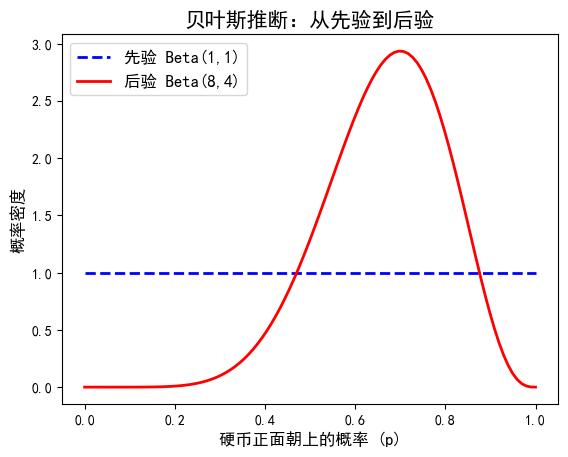

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

# 设置中文字体，防止图表显示乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]   
plt.rcParams["axes.unicode_minus"] = False

# 1. 先验分布 Beta(1, 1)
a_prior = 1
b_prior = 1
x = np.linspace(0, 1, 100)
y_prior = beta.pdf(x, a_prior, b_prior)

# 2. 后验分布 Beta(8, 4)
a_posterior = 8
b_posterior = 4
y_posterior = beta.pdf(x, a_posterior, b_posterior)

# 3. 画图
plt.plot(x, y_prior, "b--", label="先验 Beta(1,1)", linewidth=2)
plt.plot(x, y_posterior, "r-", label="后验 Beta(8,4)", linewidth=2)

# 4. 添加标题、图例和坐标轴标签
plt.title("贝叶斯推断：从先验到后验", fontsize=15)
plt.xlabel("硬币正面朝上的概率 (p)", fontsize=12)
plt.ylabel("概率密度", fontsize=12)
plt.legend(fontsize=12)

# 5. 显示图表
plt.show()
